In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')

# Understanding Credit card dataset

In [2]:
df = pd.read_csv('/kaggle/input/ccdata/CC GENERAL.csv')
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.shape

(8950, 18)

Credit card dataset has 8950 instances and 18 columns

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

The credit card dataset contains missing (null) values in two variables, __CREDIT_LIMIT__ and __MINIMUM_PAYMENTS__. This occurs because these variables do not have complete observations for all 8,950 samples, unlike the other features in the dataset.

Additionally, the dataset comprises three data types: float64 (14 features), int64 (3 features), and object (1 feature). To ensure feature comparability, improve numerical stability, and facilitate efficient model learning, data standardization will be applied to normalize the numerical variables.

### Check Correlation of numerical features

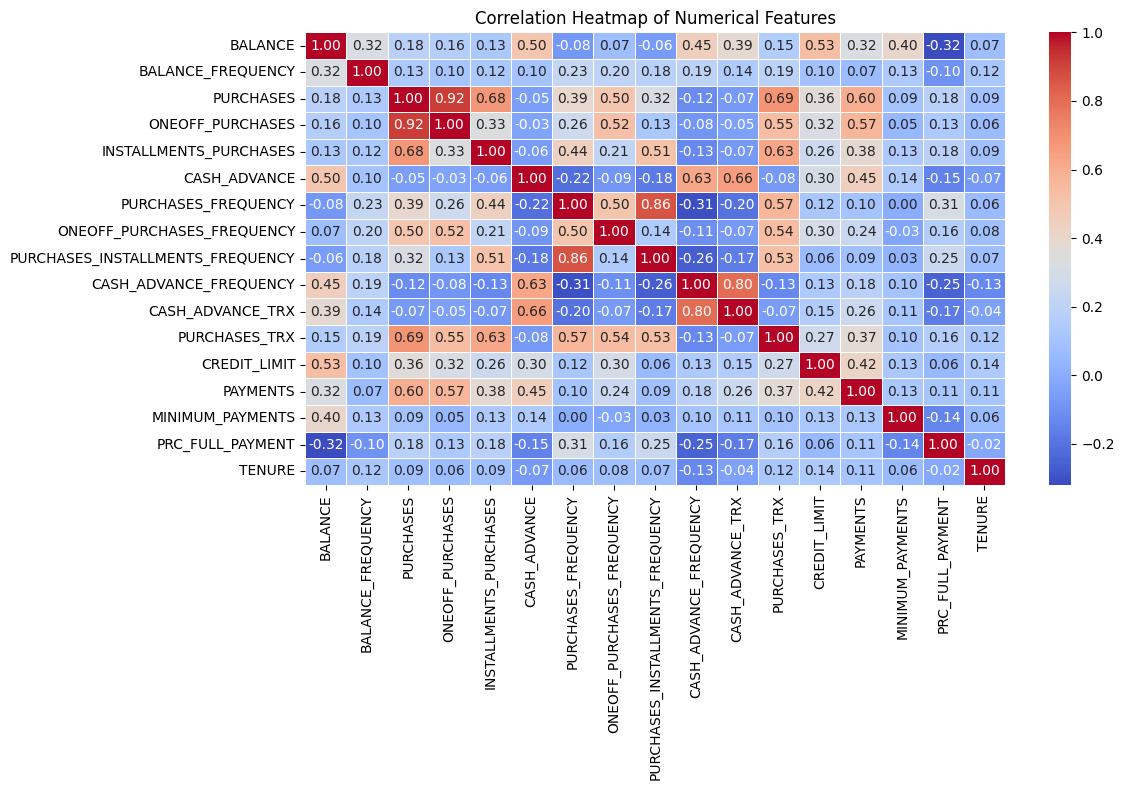

In [5]:
numeric_cols = df.select_dtypes(include=['float64','int64'])

corr = numeric_cols.corr(method='pearson')

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

The most strong positive correlated features are *Purchases* and *Oneoff_purchases*, *Purchases_frequency* and *Purchases_Installments_frequency*, but also we have two features which have negative correlation *PRC_Full_Payment* and *Tenure*.

# Data Cleaning and Preprocessing

### Handling missing values

In [6]:
# Check for missing values
df.isnull().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [7]:
# Fill null values by using median
df = df.drop('CUST_ID', axis=1)
df.fillna(df.median(), inplace=True)
df.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

Missing values handled

__In clustering analysis, the objective is not to perform predictions but to identify and group observations that exhibit similar patterns. Therefore, clustering does not involve a dependent (target) variable to be predicted.__

In [8]:
# Handle Skewness of variables
loged_df = df.copy()
for col in df.columns:
    loged_df[col] = np.log1p(df[col])

In [9]:
# Remove Outliers
def outliers(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    return df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

df = outliers(loged_df)

In [10]:
# Perform Standardization / Feature Scaling
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [11]:
# Handle Variable dimensionality using PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_scaled)
print('Number of components', pca.n_components_)

Number of components 7


## Elbow Method
Plot the Within-Cluster Sum of Squares (WCSS) as a function of the number of clusters (k). The optimal number of clusters is identified at the point where the curve begins to level off, known as the elbow.

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

wcss_list = []
silhouette_scores = []
db_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    
    wcss_list.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))

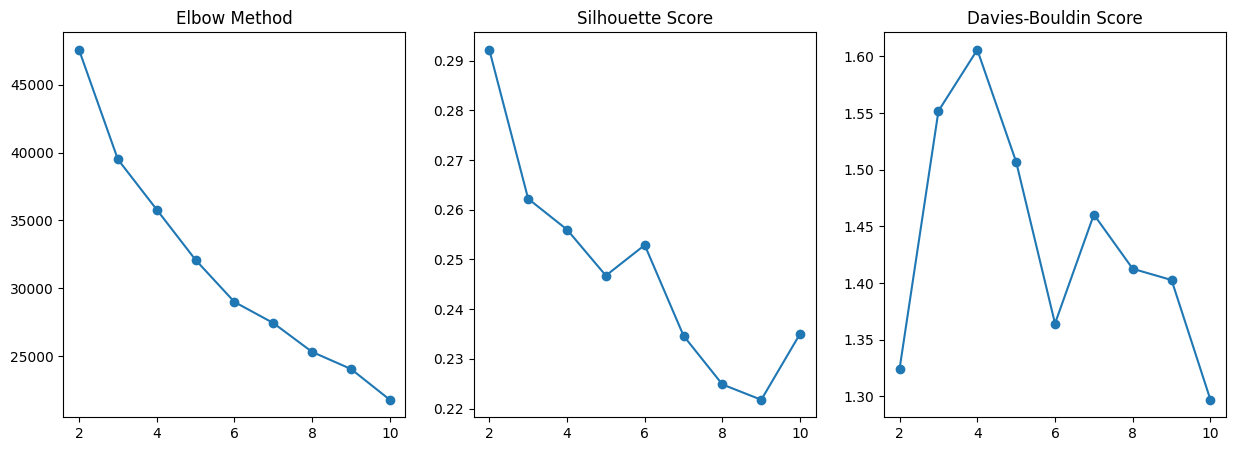

In [14]:
# Visualizing Evaluation Metrics
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(K_range, wcss_list, marker='o')
plt.title('Elbow Method')

plt.subplot(1,3,2)
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')

plt.subplot(1,3,3)
plt.plot(K_range, db_scores, marker='o')
plt.title('Davies-Bouldin Score')
plt.show()

In [15]:
from sklearn.cluster import KMeans

for k in [4, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    
    print(f"\nK = {k}")
    print("Silhouette:", silhouette_score(X_pca, labels))
    print("DB Score:", davies_bouldin_score(X_pca, labels))


K = 4
Silhouette: 0.25602101994497195
DB Score: 1.605846381285328

K = 6
Silhouette: 0.25291009556175886
DB Score: 1.364253076627082


In [16]:
optimal_k = 6

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_pca)

df['Cluster'] = labels

k = 4 was considered due to interpretability, but k = 6 was selected based on improved Davies-Bouldin score and better cluster compactness.

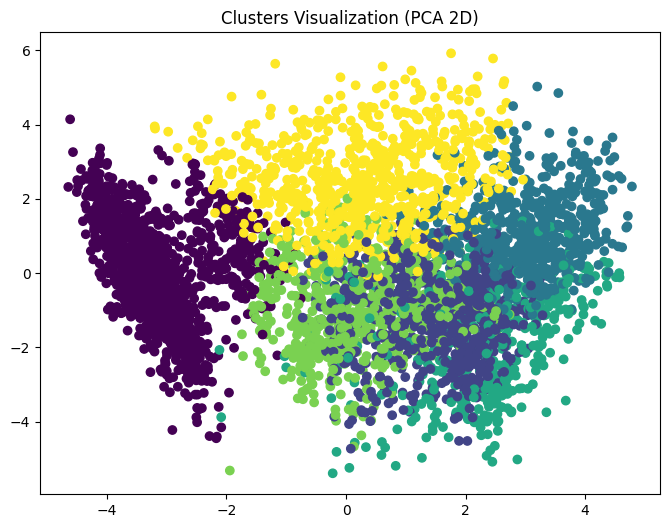

In [17]:
pca_2d = PCA(n_components=2)
X_vis = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, cmap='viridis')
plt.title("Clusters Visualization (PCA 2D)")
plt.show()

In [19]:
cluster_profile = df.groupby('Cluster').mean()
print(np.expm1(cluster_profile))

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        1690.137793           0.990272     1.023481          0.771924   
1         590.405160           0.996910   381.626033          2.140872   
2        1724.284893           0.996831  2148.483263        993.025900   
3         104.697169           0.940624   606.372414         33.625029   
4         861.383200           0.991892   307.338666        259.880127   
5        2789.840202           0.995060   845.765728        145.495783   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                      0.153854    815.879564             0.017509   
1                    339.487080      1.645075             0.732359   
2                    580.954982      1.529231             0.881817   
3                    191.025046      1.603646            

In [23]:
from IPython.display import display

cluster_summary = pd.DataFrame({
    "Cluster": [0, 1, 2, 3, 4, 5],
    "Segment Name": [
        "Cash Advance Users",
        "Installment Spenders",
        "Premium Customers",
        "Responsible Users",
        "Low Engagement Users",
        "High Debt Users"
    ],
    "Risk Level": [
        "High",
        "Medium",
        "Low",
        "Low",
        "Medium",
        "Very High"
    ],
    "Customer Value": [
        "Low",
        "Medium",
        "High",
        "Medium",
        "Low",
        "Medium"
    ]
})

cluster_summary.style.hide(axis="index")

Cluster,Segment Name,Risk Level,Customer Value
0,Cash Advance Users,High,Low
1,Installment Spenders,Medium,Medium
2,Premium Customers,Low,High
3,Responsible Users,Low,Medium
4,Low Engagement Users,Medium,Low
5,High Debt Users,Very High,Medium


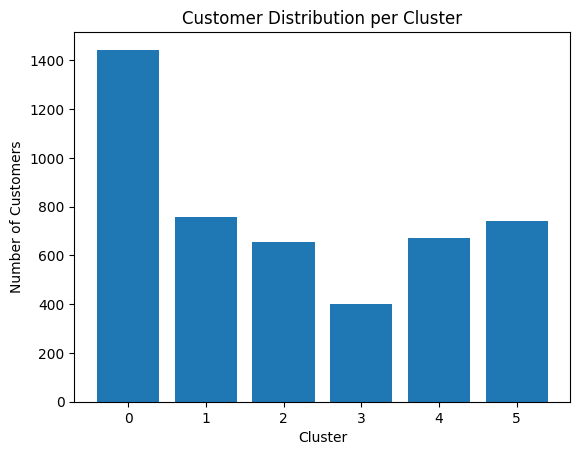

In [24]:
cluster_counts = df['Cluster'].value_counts().sort_index()

plt.figure()
plt.bar(cluster_counts.index, cluster_counts.values)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution per Cluster")
plt.show()

The cluster distribution reveals that the largest segment consists of cash-advance-dependent users, indicating a high-risk customer base. Premium customers form a smaller but valuable segment, while responsible users are the least represented. This highlights opportunities for risk management and customer value optimization.